In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from importlib import reload
import util
reload(util)

<module 'util' from '/home/davidclark/Projects/LDR-Dimensionality/util.py'>

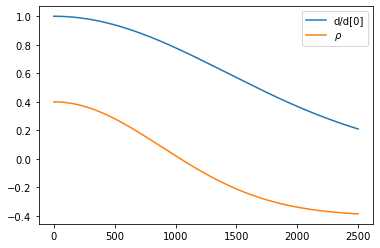

g_eff = 2.8150759450584157


100%|███████████████████████████████████| 49999/49999 [00:05<00:00, 9970.21it/s]


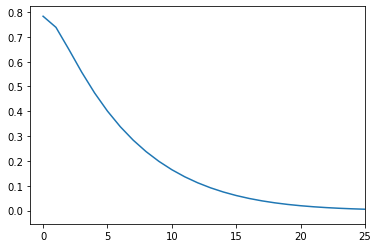

In [13]:
reload(util)

N = 2500

#define d and rho
d = 4*util.gen_spect(N, 0.8, power=2)
rho = 0.8*util.gen_spect(N, 0.5, power=2) - 0.4
plt.plot(d/d[0], label="d/d[0]")
plt.plot(rho, label="$\\rho$")
plt.legend()
plt.show()

#get effective g (determines dynamcis when rho = 0)
print("g_eff =", np.sqrt((d**2).mean().item()))

#sample weights
J = util.gen_LDR(d=d, rho=rho)

#run simulation
X = util.run_sim(
    T=2500, dt=0.05, T_eval=1, J=J.to(0), N_batch=10)

#plot empirical autocov
C = util.compute_C(torch.tanh(X.to(0)), 0).cpu()
plt.plot(C)
plt.xlim(-1, 25)
plt.show()

  5%|██▏                                        | 5/100 [00:04<01:21,  1.17it/s]

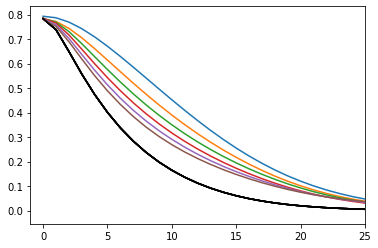

  9%|███▊                                       | 9/100 [00:08<01:22,  1.11it/s]


KeyboardInterrupt: 

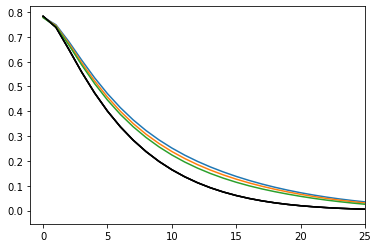

In [14]:
reload(util)

#define callback function for solving LDR DMFT
#(plots current DMFT estimate and empirical estimate in black)
def callback_fn(C_current, S_current, i):
    plt.plot(C_current.cpu()[::20])
    plt.plot(C, color='black')
    plt.xlim(-1, 25)
    if i >= 1 and i % 5 == 0:
        plt.show()

#run DMFT solver loop
dt = 0.05
C_dmft, S_dmft = util.solve_dmft(
    update_fn=(lambda C, S:
               util.update_LDR_sym(d.to(0), rho.to(0), C, S, N_samples=4096, dt=dt)),
    callback_fn=callback_fn,
    init_dt=dt,
    N_t=2048,
    num_iter=100,
    device=0,
    alpha=0.8)